# Crypto XS Momentum

The second strategy of the course, one section per brick. The tutorial version, with every step drawn on real data, is `02_tutorial_step_by_step.ipynb`.

**The hypothesis (Pass 1).** Inside crypto, relative strength persists for weeks: retail chases recent winners and drops losers, and information spreads slowly across hundreds of names. A long/short book captures it without the market bet, which in crypto is most of any long-only result.

| Section | Brick | Lesson |
| --- | --- | --- |
| 1 | Data | 2.4 |
| 2 | Universe: point-in-time vs frozen | 2.4 |
| 3 | Signal: three speeds, FDM, cross-sectional | 2.5 |
| 4 | Sizing: inverse vol, IDM, buffer | 2.6 |
| 5 | Backtest and diagnostic | 2.7 |
| 6 | The cost of survivorship | 2.4 / 2.7 |
| 7 | Regimes and concentration | 2.8 |
| 8 | Variants: buffer and costs | 2.9 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = "../data_trend"
PPY = 365                       # crypto trades every day
TARGET_VOL = 0.20               # annual vol target for this strategy
FEE_BPS = 5.0                   # one-way cost assumption
BUFFER = 0.10                   # do not trade if the gap to the ideal position is below 10 %
N_UNIVERSE = 20                 # names held at any time (beyond that, names get small, noisy and costly to trade)
plt.rcParams.update({"figure.figsize": (12, 4.5), "axes.grid": True, "grid.alpha": .3})

## 1. Data

Daily close, funding rate and quote volume for every USDT perpetual that ever traded on Binance. Three wide tables: one row per day, one column per name.

In [2]:
long = pd.read_parquet(f"{DATA}/prices_funding.parquet")
PX   = long.pivot(index="date", columns="symbol", values="close").sort_index()
FUND = long.pivot(index="date", columns="symbol", values="funding_rate").reindex(PX.index).fillna(0.0)
VOLUME = pd.read_parquet(f"{DATA}/volume_all_perps.parquet").reindex(PX.index)   # quote volume, all perps ever
meta = pd.read_csv(f"{DATA}/perp_meta.csv")
today40 = pd.read_csv(f"{DATA}/universe_today.csv")["symbol"].tolist()

print(f"{PX.shape[1]} names with prices, {VOLUME.shape[1]} names with volume, {PX.index.min():%Y-%m-%d} -> {PX.index.max():%Y-%m-%d}")
PX[["BTCUSDT", "ETHUSDT", "SOLUSDT"]].dropna().tail(3)

450 names with prices, 832 names with volume, 2019-12-31 -> 2026-08-24


symbol,BTCUSDT,ETHUSDT,SOLUSDT
date,,,
2026-08-22,77084.5,2421.40,93.83
2026-08-23,77719.1,2462.58,95.44
2026-08-24,78953.0,2481.03,98.96


## 2. Universe: who is in the top 20 *at each date*

The rule, applied every day with only what was known that day:
1. crypto perpetuals only (Binance now lists perps on stocks and gold; not the same market);
2. listed for at least 180 days (a fresh listing dominates volume rankings by novelty);
3. ranked on the **trailing 30-day** average volume, lagged one day (a one-day squeeze must not decide);
4. **hysteresis**: enter at rank ≤ 20, leave only at rank > 25. Without it, names flicker in and out at the boundary and each flicker is a forced trade.

Why 20? Written before looking: beyond the twentieth rank, names get small, noisy, and a 5 bp cost assumption stops being realistic.

The control is the **frozen** universe: today's top 20, applied to the whole past. That is what most backtests do, and it is survivorship bias.

/sessions/rcw-01bjyvmp9cq5hisor6mgbcjf/tmp/ipykernel_10/3772650786.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  M_PIT = point_in_time_universe(VOLUME).reindex(columns=PX.columns).fillna(False) & PX.notna()


point-in-time : 176 names ever in the universe, 20 held per day (median)
frozen        : 20 names, 12 held per day (median)
entries + exits per year, point-in-time: {Timestamp('2019-12-31 00:00:00'): 0, Timestamp('2020-12-31 00:00:00'): 26, Timestamp('2021-12-31 00:00:00'): 72, Timestamp('2022-12-31 00:00:00'): 142, Timestamp('2023-12-31 00:00:00'): 132, Timestamp('2024-12-31 00:00:00'): 148, Timestamp('2025-12-31 00:00:00'): 102, Timestamp('2026-12-31 00:00:00'): 98}


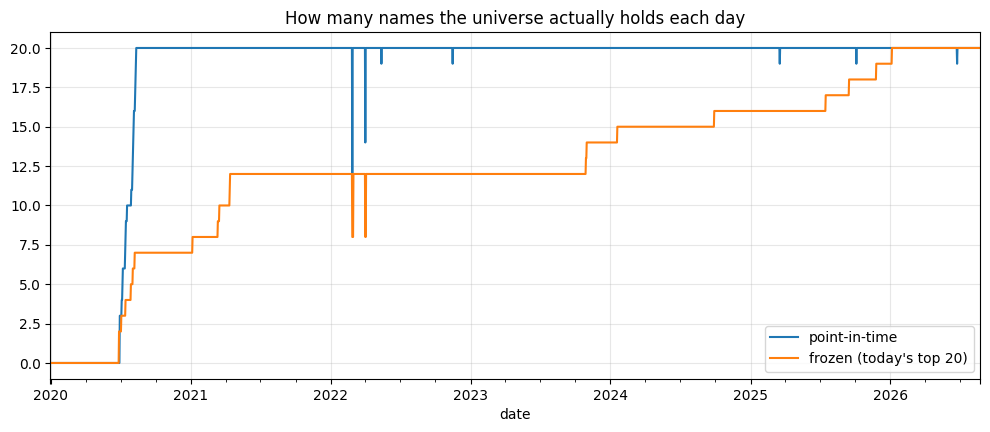

In [3]:
def point_in_time_universe(volume, n=N_UNIVERSE, win=30, min_age=180, max_gap=14):
    """Boolean table (date x name): True = in the universe that day. Uses only past data."""
    is_crypto = dict(zip(meta.symbol, meta.underlying_type))
    vol = volume[[c for c in volume.columns if is_crypto.get(c, "COIN") == "COIN"]]

    # days listed in the current listing episode (a gap > 14 days restarts the count: recycled tickers)
    age = pd.DataFrame(np.nan, index=vol.index, columns=vol.columns)
    for c in vol.columns:
        days = vol[c].dropna().index
        if len(days):
            episode = (days.to_series().diff().dt.days > max_gap).cumsum()
            age.loc[days, c] = episode.groupby(episode).cumcount().values + 1

    score = vol.rolling(win, min_periods=win).mean().shift(1)            # known before today
    eligible = score.notna() & (age.shift(1) >= min_age)
    rank = score.where(eligible).rank(axis=1, ascending=False, method="first").values

    buffer = n // 4
    members = np.zeros(rank.shape, bool)
    current = np.zeros(rank.shape[1], bool)
    for i in range(len(rank)):
        ok = ~np.isnan(rank[i]) & (rank[i] <= n + buffer)
        current = current & ok                            # leave only beyond n + buffer
        free = n - current.sum()
        if free > 0:                                      # fill free slots with the best-ranked outsiders
            cand = np.where(~current & ok)[0]
            current[cand[np.argsort(rank[i][cand])][:free]] = True
        members[i] = current
    return pd.DataFrame(members, index=vol.index, columns=vol.columns)

M_PIT = point_in_time_universe(VOLUME).reindex(columns=PX.columns).fillna(False) & PX.notna()

# the frozen control: today's top 20 by volume, whenever they have a price (and 180 days of history)
today20 = VOLUME.tail(30).mean()[[c for c in today40 if c in VOLUME.columns]].nlargest(N_UNIVERSE).index.tolist()
listed_days = PX.notna().cumsum()
M_FROZEN = pd.DataFrame({c: (c in today20) & PX[c].notna() & (listed_days[c] >= 180) for c in PX.columns})

print(f"point-in-time : {M_PIT.any().sum()} names ever in the universe, {M_PIT.sum(axis=1).median():.0f} held per day (median)")
print(f"frozen        : {M_FROZEN.any().sum()} names, {M_FROZEN.sum(axis=1).median():.0f} held per day (median)")
churn = M_PIT.astype(int).diff().abs().sum(axis=1).resample("YE").sum()
print("entries + exits per year, point-in-time:", churn.astype(int).to_dict())

fig, ax = plt.subplots()
M_PIT.sum(axis=1).plot(ax=ax, label="point-in-time"); M_FROZEN.sum(axis=1).plot(ax=ax, label="frozen (today's top 20)")
ax.set_title("How many names the universe actually holds each day"); ax.legend(); plt.show()

The frozen universe is **narrow** before 2024: many of today's top names did not exist yet. And most names that ever passed through the point-in-time top 20 are not there today: a frozen backtest never sees them.

## 3. Signal

Order matters:
1. **vol-adjust** the daily returns (r / σ), otherwise a 150 %-vol memecoin always ranks above BTC;
2. **three speeds**: sum the vol-adjusted returns over 7, 30 and 90 days (skip today's bar, it is not observable when you decide);
3. **smooth** each speed with an EMA of span h / 4, to cut turnover on the fast one;
4. divide by √h so the three are comparable, **average** them, multiply by the FDM (averaging correlated signals shrinks them; the FDM scales back);
5. **cross-sectional**: subtract the weighted average across the universe, so that the sum of *positions* is zero: long the strongest, short the weakest, no market bet;
6. scale so that the average |forecast| is 10, cap at ±20, re-centre.

In [4]:
def ewma_vol(px, span=32):
    """Daily volatility, exponentially weighted. Blended with its long-run mean so it never collapses."""
    fast = px.pct_change(fill_method=None).ewm(span=span, min_periods=20).std()
    slow = fast.rolling(10 * PPY, min_periods=PPY).mean()
    return 0.7 * fast + 0.3 * slow.fillna(fast.expanding(min_periods=1).mean())

VOL_D = ewma_vol(PX)                                   # daily
VOL_A = VOL_D * np.sqrt(PPY)                           # annualised
Z = PX.pct_change(fill_method=None) / VOL_D                            # vol-adjusted daily returns

HORIZONS = (7, 30, 90)
speeds = {}
for h in HORIZONS:
    s = Z.rolling(h, min_periods=h).sum().shift(1)                       # skip today's bar
    s = s.ewm(span=max(2, round(h / 4)), min_periods=1).mean()           # smooth
    speeds[h] = s / np.sqrt(h)                                           # comparable scale

# FDM: one number, from the average correlation between the three speeds (pooled over names)
rho = np.nanmean([speeds[a].corrwith(speeds[b]).median() for a in HORIZONS for b in HORIZONS if a < b])
FDM = 1 / np.sqrt((1 + 2 * rho) / 3)
raw = sum(speeds.values()) / 3 * FDM
print(f"average correlation between speeds {rho:.2f} -> FDM {FDM:.2f}")

def cross_sectional_forecast(raw, members, cap=20):
    """Directional score -> market-neutral forecast, avg |f| = 10, capped, sum of positions = 0."""
    w = members.div(members.sum(axis=1), axis=0).fillna(0.0)             # 1/n on the day's members
    k = (w / VOL_A).where(members)                                        # position per unit of forecast
    s = raw.where(members)
    def demean(f):
        return f.sub((f * k).sum(axis=1) / k.sum(axis=1), axis=0)
    f = demean(s)
    f = f.mul(10 / f.abs().mean(axis=1).expanding(min_periods=PPY).mean(), axis=0)   # pooled scale, past only
    for _ in range(20):                                                    # cap, then re-centre, until stable
        f = demean(f.clip(-cap, cap))
    return f.where(members, 0.0), w

FC_PIT, W_PIT = cross_sectional_forecast(raw, M_PIT)
FC_FRZ, W_FRZ = cross_sectional_forecast(raw, M_FROZEN)

d = FC_PIT.dropna(how="all").index[-1]
print(f"\nForecast on {d:%Y-%m-%d}, strongest and weakest:")
print(FC_PIT.loc[d][M_PIT.loc[d]].sort_values().round(1).iloc[[0, 1, 2, -3, -2, -1]].to_string())

average correlation between speeds 0.30 -> FDM 1.37



Forecast on 2026-08-24, strongest and weakest:
symbol
BEATUSDT   -20.0
CYSUSDT    -20.0
DEXEUSDT   -20.0
HYPEUSDT    11.8
ZECUSDT     17.8
TUTUSDT     19.6


## 4. Sizing

- **Inverse vol**: each name gets `target_vol / σ`, so that BTC and a memecoin carry the same risk.
- **1 / n** across the day's members.
- **IDM**: 20 imperfectly correlated positions produce less vol than the target. The IDM scales the book back up, is measured on the past only (yearly, expanding), and can never exceed √20: a book of 20 independent bets diversifies no further than that. The first year runs at IDM 1: no diversification credit until it is measured.
- **Buffer**: trade only when the gap between the current and the ideal position exceeds 10 % of the full-size position.

In [5]:
def buffered(target, full_size, f=BUFFER):
    """Only move when outside the band [target - f*full, target + f*full]. One name, one loop."""
    t, b = target.values, f * full_size.values
    out, cur = np.empty(len(t)), 0.0
    for i in range(len(t)):
        lo, hi = t[i] - b[i], t[i] + b[i]
        cur = lo if cur < lo else (hi if cur > hi else cur)
        out[i] = cur
    return pd.Series(out, index=target.index)

def positions(FC, W, idm=1.0, f=BUFFER, max_lev=15.0):
    """Position in units of capital, per name: forecast/10 x full size, capped, buffered."""
    full = (W / VOL_A).mul(idm, axis=0).mul(TARGET_VOL).reindex(FC.index).fillna(0.0)   # idm is per date
    target = (FC / 10 * full).clip(-max_lev * full, max_lev * full)
    return pd.DataFrame({c: buffered(target[c].fillna(0.0), full[c], f) for c in FC.columns})

def pnl(P, fee_bps=FEE_BPS):
    """Daily P&L: price return + funding collected - costs, position held = yesterday's."""
    held = P.shift(1)
    price = (held * PX.pct_change(fill_method=None)).fillna(0.0).sum(axis=1)
    fund  = (-held * FUND).fillna(0.0).sum(axis=1)           # long pays funding, short collects it
    cost  = (held.diff().abs() * fee_bps / 1e4).fillna(0.0).sum(axis=1)
    return pd.DataFrame({"price": price, "funding": fund, "cost": -cost, "total": price + fund - cost})

def expanding_idm(R, min_days=180):
    """target / realised vol of the un-scaled book, on past years only, from its first trading day."""
    R = R.loc[R.ne(0).idxmax():]                       # leave out the days before the strategy starts
    out = pd.Series(1.0, index=R.index)
    for y in sorted(set(R.index.year))[1:]:
        past = R[R.index.year < y]
        if len(past) >= min_days and past.std() > 0:
            out[R.index.year == y] = min(TARGET_VOL / (past.std() * np.sqrt(PPY)), np.sqrt(N_UNIVERSE))   # never more than sqrt(n)
    return out

def run(FC, W, fee_bps=FEE_BPS, f=BUFFER):
    P0 = positions(FC, W, 1.0, f)
    idm = expanding_idm(pnl(P0, fee_bps)["total"]).reindex(FC.index).fillna(1.0)
    P = positions(FC, W, idm, f)
    R = pnl(P, fee_bps)
    start = P.abs().sum(axis=1).gt(0).idxmax()
    return P.loc[start:], R.loc[start:], idm

P_PIT, R_PIT, IDM_PIT = run(FC_PIT, W_PIT)
print(f"IDM by year: {IDM_PIT.groupby(IDM_PIT.index.year).first().round(2).to_dict()}")

IDM by year: {2019: 1.0, 2020: 1.0, 2021: 1.0, 2022: 4.47, 2023: 4.47, 2024: 4.47, 2025: 4.47, 2026: 4.47}


## 5. Backtest and diagnostic

This backtest **diagnoses**, it does not validate. Then a block bootstrap: a Sharpe is a point, the range is what you remember.

Sharpe                  0.74
t-stat                  1.69
CAGR %                 12.41
Vol %                  17.84
Max drawdown %        -22.80
Turnover x/yr          31.62
Breakeven cost (bp)    47.03
P&L price %            52.62
P&L funding %          24.13
P&L costs %            -8.16

What this history could also have looked like (block bootstrap, 5-95 % range):
                  5 %  median   95 %
Sharpe           0.19    0.86   1.52
Vol %           15.92   17.95  19.91
Max drawdown % -33.26  -20.68 -13.67


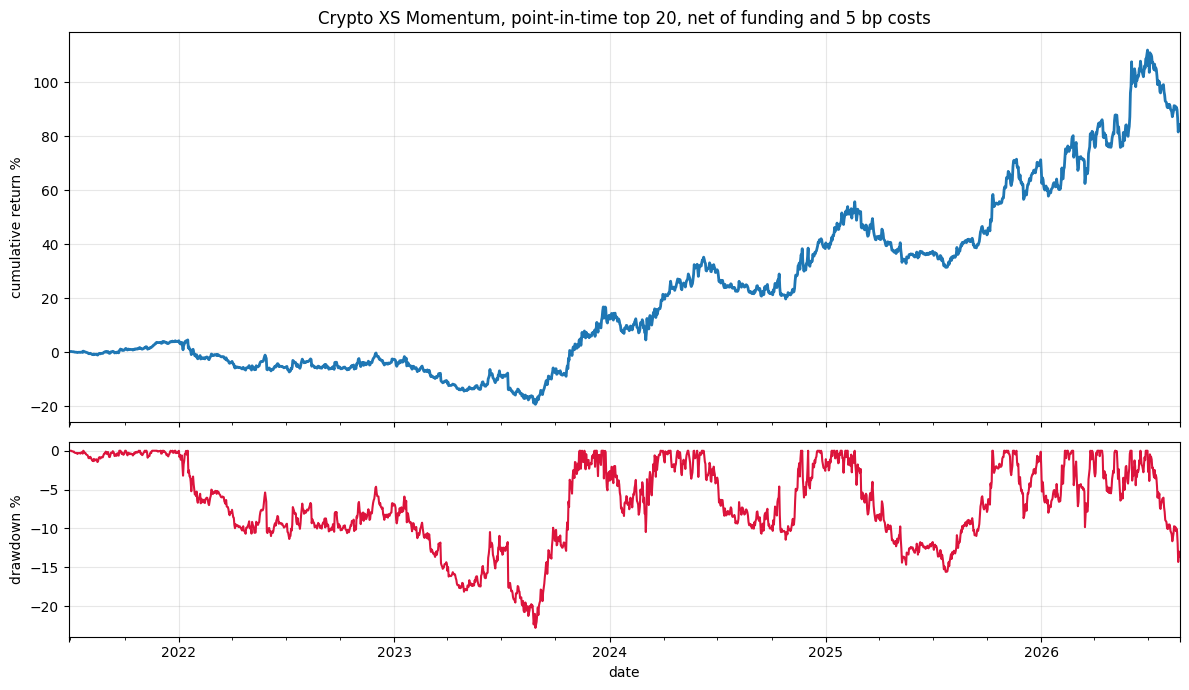

In [6]:
def t_stat(r):
    return r.mean() / r.std() * np.sqrt(len(r))

def diagnostic(P, R):
    r = R["total"]
    eq = (1 + r).cumprod(); dd = eq / eq.cummax() - 1
    turnover = P.diff().abs().sum(axis=1).mean() * PPY
    traded = P.diff().abs().sum(axis=1).sum()
    return pd.Series({
        "Sharpe": r.mean() / r.std() * np.sqrt(PPY),
        "t-stat": t_stat(r),
        "CAGR %": (eq.iloc[-1] ** (PPY / len(r)) - 1) * 100,
        "Vol %": r.std() * np.sqrt(PPY) * 100,
        "Max drawdown %": dd.min() * 100,
        "Turnover x/yr": turnover,
        "Breakeven cost (bp)": (R["price"] + R["funding"]).sum() / traded * 1e4,
        "P&L price %": R["price"].sum() * 100,
        "P&L funding %": R["funding"].sum() * 100,
        "P&L costs %": R["cost"].sum() * 100,
    })

diag_pit = diagnostic(P_PIT, R_PIT)
print(diag_pit.round(2).to_string())

def bootstrap_ranges(r, block=63, n=2000, seed=0):
    # resample the daily returns in 3-month blocks: what else could this history have looked like?
    a, rng, out = r.values, np.random.default_rng(seed), []
    for _ in range(n):
        starts = rng.integers(0, len(a) - block, len(a) // block + 1)
        s = np.concatenate([a[i:i + block] for i in starts])[:len(a)]
        eq = np.cumprod(1 + s)
        out.append((s.mean() / s.std() * np.sqrt(PPY), s.std() * np.sqrt(PPY) * 100, (eq / np.maximum.accumulate(eq) - 1).min() * 100))
    out = pd.DataFrame(out, columns=["Sharpe", "Vol %", "Max drawdown %"])
    return out.quantile([0.05, 0.5, 0.95]).T.rename(columns={0.05: "5 %", 0.5: "median", 0.95: "95 %"})

print()
print("What this history could also have looked like (block bootstrap, 5-95 % range):")
print(bootstrap_ranges(R_PIT["total"]).round(2).to_string())

eq = (1 + R_PIT["total"]).cumprod()
fig, ax = plt.subplots(2, 1, figsize=(12, 7), height_ratios=[2, 1], sharex=True)
((eq - 1) * 100).plot(ax=ax[0], lw=2); ax[0].set_ylabel("cumulative return %"); ax[0].set_title("Crypto XS Momentum, point-in-time top 20, net of funding and 5 bp costs")
(eq / eq.cummax() - 1).mul(100).plot(ax=ax[1], color="crimson"); ax[1].set_ylabel("drawdown %")
plt.tight_layout(); plt.show()

Read the P&L split first: how much is price (momentum), how much is funding collected by the shorts (carry).

## 6. The cost of survivorship

Same signal, same sizing, same costs. The only thing that changes is who is in the universe.

                     point-in-time  frozen (today's 20)
Sharpe                        0.74                 0.82
t-stat                        1.69                 1.87
CAGR %                       12.41                14.07
Vol %                        17.84                17.97
Max drawdown %              -22.80               -18.92
Turnover x/yr                31.62                33.94
Breakeven cost (bp)          47.03                48.54
P&L price %                  52.62                83.45
P&L funding %                24.13                 1.67
P&L costs %                  -8.16                -8.77


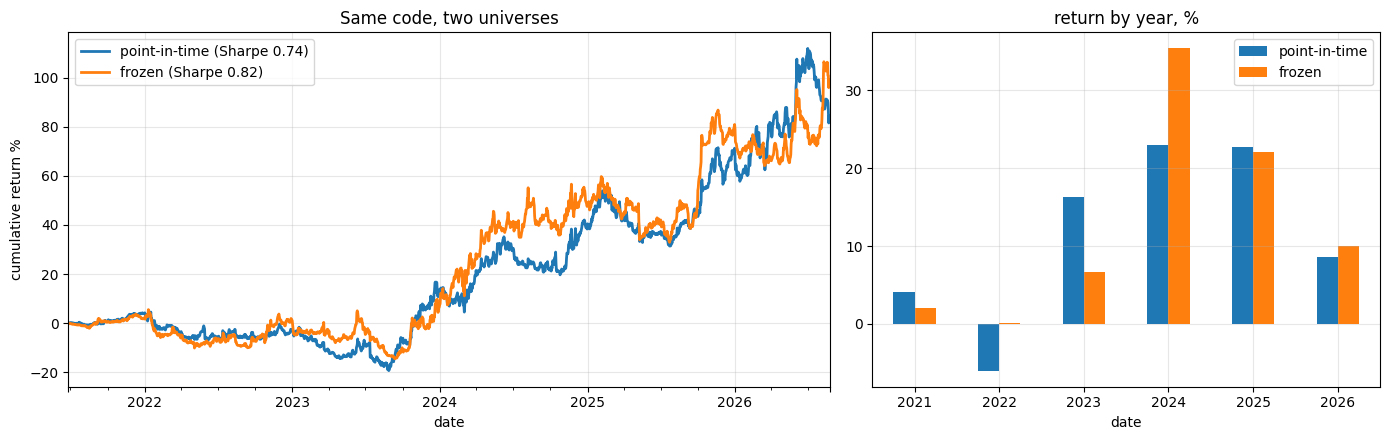

In [7]:
P_FRZ, R_FRZ, _ = run(FC_FRZ, W_FRZ)
diag_frz = diagnostic(P_FRZ, R_FRZ)
cmp = pd.DataFrame({"point-in-time": diag_pit, "frozen (today's 20)": diag_frz}).round(2)
print(cmp.to_string())

yearly = pd.DataFrame({"point-in-time": R_PIT["total"].resample("YE").sum() * 100,
                       "frozen": R_FRZ["total"].resample("YE").sum() * 100})
yearly.index = yearly.index.year

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), width_ratios=[1.5, 1])
(((1 + R_PIT["total"]).cumprod() - 1) * 100).plot(ax=ax[0], lw=2, label=f"point-in-time (Sharpe {diag_pit['Sharpe']:.2f})")
(((1 + R_FRZ["total"]).cumprod() - 1) * 100).plot(ax=ax[0], lw=2, label=f"frozen (Sharpe {diag_frz['Sharpe']:.2f})")
ax[0].set_ylabel("cumulative return %"); ax[0].legend(); ax[0].set_title("Same code, two universes")
yearly.plot.bar(ax=ax[1]); ax[1].set_title("return by year, %"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

The frozen universe makes almost all its money on price: it holds, in 2021, the names that would become large by 2026. The honest universe makes a third on funding. The Sharpes are close here because today's largest names were mostly large already; deeper in the ranking the gap widens fast.

## 7. Regimes and concentration

Pass 1: works when coins disperse, suffers when everything moves together. Then how much of the P&L a few names and a few days carry.

In [8]:
r = R_PIT["total"]
# dispersion = cross-sectional std of daily returns across the universe, by month
rm = r.resample("ME").sum()                                            # the months the strategy traded
disp = PX.pct_change(fill_method=None).where(M_PIT).std(axis=1).resample("ME").mean().reindex(rm.index)
hi = disp > disp.median()
regime = pd.DataFrame({
    "months": [hi.sum(), (~hi).sum()],
    "mean monthly return %": [rm[hi].mean() * 100, rm[~hi].mean() * 100],
    "hit rate %": [(rm[hi] > 0).mean() * 100, (rm[~hi] > 0).mean() * 100],
}, index=["high dispersion", "low dispersion"]).round(2)
print(regime.to_string())

# concentration
by_name = ((P_PIT.shift(1) * PX.pct_change(fill_method=None) - P_PIT.shift(1) * FUND).fillna(0).sum()).sort_values(ascending=False)
top5 = by_name.head(5)
print(f"\nTop 5 names = {top5.sum() / by_name.sum() * 100:.0f} % of P&L : {', '.join(f'{k} {v*100:+.0f}%' for k, v in top5.items())}")
top10d = r.nlargest(10)
without = r.drop(top10d.index)
print(f"Top 10 days = {top10d.sum() / r.sum() * 100:.0f} % of P&L ; Sharpe without them {without.mean() / without.std() * np.sqrt(PPY):.2f}")
print(f"P&L from names NOT in today's top 20: {by_name[[c for c in by_name.index if c not in today20]].sum() / by_name.sum() * 100:.0f} %")

                 months  mean monthly return %  hit rate %
high dispersion      31                   1.78       67.74
low dispersion       32                   0.42       46.88

Top 5 names = 69 % of P&L : SUIUSDT +13%, SIRENUSDT +11%, BTCUSDT +10%, LABUSDT +9%, SOLUSDT +9%
Top 10 days = 60 % of P&L ; Sharpe without them 0.32
P&L from names NOT in today's top 20: 36 %


## 8. Variants: buffer and costs

The buffer sweep, then the cost assumption. Every line is a row in the Research Log.

In [9]:
rows = {}
for f in (0.0, 0.05, 0.10, 0.20):
    P, R, _ = run(FC_PIT, W_PIT, f=f)
    d = diagnostic(P, R)
    rows[f"buffer {int(f*100)} %"] = d[["Sharpe", "Turnover x/yr", "P&L costs %"]]
print(pd.DataFrame(rows).T.round(2).to_string())

print("\nCost sensitivity, buffer 10 %:")
rows = {}
for fee in (1.0, 5.0, 10.0, 20.0):
    P, R, _ = run(FC_PIT, W_PIT, fee_bps=fee)
    rows[f"{int(fee)} bp"] = diagnostic(P, R)[["Sharpe", "CAGR %"]]
print(pd.DataFrame(rows).T.round(2).to_string())

             Sharpe  Turnover x/yr  P&L costs %
buffer 0 %     0.70          45.62       -11.77
buffer 5 %     0.74          36.91        -9.53
buffer 10 %    0.74          31.62        -8.16
buffer 20 %    0.77          24.62        -6.35

Cost sensitivity, buffer 10 %:


       Sharpe  CAGR %
1 bp     0.82   13.84
5 bp     0.74   12.41
10 bp    0.66   10.64
20 bp    0.48    7.20
